In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

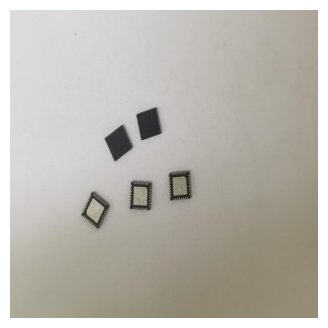

In [28]:
img = cv2.imread("data/image/image5_jpg.rf.69e9fcc7fab3bfb62258753dc9c04469.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [29]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

In [30]:
def show(threshold):

    _, binary = cv2.threshold(blur, threshold, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(4,4))

    plt.imshow(binary, cmap="gray")

    plt.axis("off")

    plt.show()

interact(show, threshold=IntSlider(min=0, max=255, step=1, value=128))

interactive(children=(IntSlider(value=128, description='threshold', max=255), Output()), _dom_classes=('widget…

<function __main__.show(threshold)>

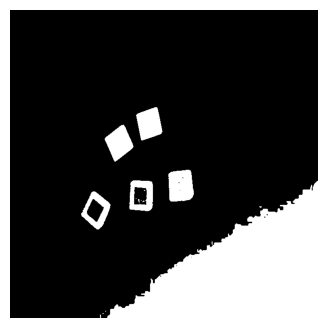

In [31]:
_, binary = cv2.threshold(blur, 147, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(4,4))
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

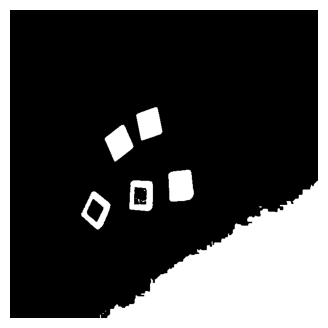

In [32]:
close = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, np.ones((3, 3), dtype=np.uint8))

plt.figure(figsize=(4,4))
plt.imshow(close, cmap="gray")
plt.axis("off")
plt.show()

In [33]:
contours, _ = cv2.findContours(close, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filtered_contours = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 1000:
        filtered_contours.append(cnt)

In [49]:
def extract_shape_features(cnt):

    features = {}

    area = cv2.contourArea(cnt)

    perim = cv2.arcLength(cnt, True)

    features["area"] = area

    features["perimeter"] = perim

    # --- Compactness (Circularity) ---

    features["compactness"] = (4 * np.pi * area) / (perim * perim) if perim > 0 else 0

    # --- Convex Hull ---

    hull = cv2.convexHull(cnt)

    hull_area = cv2.contourArea(hull)

    hull_perim = cv2.arcLength(hull, True)

    features["hull_area"] = hull_area

    features["hull_perimeter"] = hull_perim

    # Solidity = area / hull_area

    features["solidity"] = area / hull_area if hull_area > 0 else 0

    # Roughness = perimeter / hull_perimeter

    features["roughness"] = perim / hull_perim if hull_perim > 0 else 0

    # --- Bounding Rect ---

    x, y, w, h = cv2.boundingRect(cnt)

    features["bbox_x"] = x

    features["bbox_y"] = y

    features["bbox_w"] = w

    features["bbox_h"] = h

    features["aspect_ratio"] = w / h if h > 0 else 0

    # --- Min Area Rect (rotated rectangle) ---

    rect = cv2.minAreaRect(cnt)

    (rw, rh) = rect[1]

    major = max(rw, rh)

    minor = min(rw, rh)

    features["minAreaRect_w"] = rw

    features["minAreaRect_h"] = rh

    features["elongation_rect"] = major / minor if minor > 0 else 0

    features["angle_rect"] = rect[2]

    # --- Ellipse fit (better elongation, if enough points) ---

    if len(cnt) >= 5:

        (cx, cy), (MA, ma), angle = cv2.fitEllipse(cnt)

        major_e = max(MA, ma)

        minor_e = min(MA, ma)

        features["ellipse_major"] = major_e

        features["ellipse_minor"] = minor_e

        features["ellipse_angle"] = angle

        features["elongation_ellipse"] = major_e / minor_e if minor_e > 0 else 0

    else:

        features["ellipse_major"] = None

        features["ellipse_minor"] = None

        features["ellipse_angle"] = None

        features["elongation_ellipse"] = None

    # --- moments ---
    M = cv2.moments(cnt)
    features["m00"] = M["m00"]
    features["m10"] = M["m10"]
    features["m01"] = M["m01"]
    features["m20"] = M["m20"]
    features["m11"] = M["m11"]
    features["m02"] = M["m02"]

    # --- approximate points ---
    epsilon = 0.1 * cv2.arcLength(cnt, True)    
    features["approx_points"] = cv2.approxPolyDP(cnt, epsilon, closed=True)

    # --- rectangularity = area / (w * h) ---
    features["rectangularity"] = area / (rw * rh) if rw > 0 and rh > 0 else 0

    # --- check if the blob touch edge ---
    inflate = 3
    img_h, img_w = img.shape[:2]

    touch_edge = (
        x <= inflate or
        y <= inflate or
        x + w >= img_w - inflate or
        y + h >= img_h - inflate
    )
    features["touch_edge"] = touch_edge

    # --- valid blob ---
    features["valid"] = True

    return features


cnt_features = []

for i, cnt in enumerate(filtered_contours):
    f = extract_shape_features(cnt)
    f["id"] = i
    cnt_features.append(f)

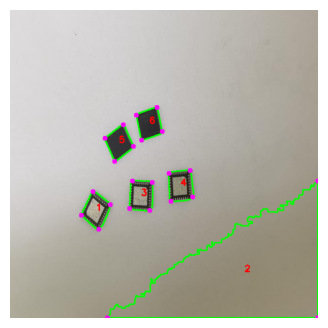

In [36]:
cnt_img = img.copy()

for cnt, f in zip(filtered_contours, cnt_features):
    # draw contour
    cv2.drawContours(cnt_img, [cnt], -1, (0, 255, 0), 2)

    # put contour id
    id = f["id"]
    if f["m00"] != 0:
        cx = int(f["m10"] / f["m00"])
        cy = int(f["m01"] / f["m00"])

    else:
        x, y, w, h = f["bbox_x"], f["bbox_y"], f["bbox_w"], f["bbox_h"]
        cx, cy = x + w // 2, y + h // 2

    cv2.putText(cnt_img, str(id+1), (cx, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    
    # draw corner points
    for pt in f["approx_points"]:
        px, py = pt[0]
        cv2.circle(cnt_img, (px, py), 5, (255, 0, 255), -1)

plt.figure(figsize=(4,4))
plt.imshow(cnt_img)
plt.axis("off")
plt.show()

In [37]:
print(f"id roughness compactness approx_points rectangularity touch_edge")
for f in cnt_features:
    id = f["id"]
    area = f["area"]
    roughness = f["roughness"]
    compactness = f["compactness"]
    approx_points = len(f["approx_points"])
    rectangularity = f["rectangularity"]
    touch_edge = f["touch_edge"]
    print(f"{id+1} {area} {roughness:.3f} {compactness:.3f} {approx_points} {rectangularity:.3f} {touch_edge}")

id roughness compactness approx_points rectangularity touch_edge
1 2838.5 1.055 0.751 4 0.814 False
2 64766.5 1.230 0.346 3 0.522 True
3 2793.5 1.029 0.795 4 0.929 False
4 2946.0 1.036 0.793 4 0.906 False
5 2568.0 1.060 0.714 4 0.814 False
6 2570.0 1.065 0.716 4 0.885 False


In [75]:
for cnt, f in zip(filtered_contours, cnt_features):
    touch_edge = f["touch_edge"]
    roughness = f["roughness"]
    compactness = float(f["compactness"])
    rectangularity = float(f["rectangularity"])

    if touch_edge == True and roughness > 1.100 and compactness < 0.7 and rectangularity < 0.8:
        f["valid"] = False

for i, f in enumerate(cnt_features):
    f["id"] = i
    print(f"{f['id']} {f['valid']} {f['area']}")        

0 True 2838.5
1 False 64766.5
2 True 2793.5
3 True 2946.0
4 True 2568.0
5 True 2570.0


In [79]:
# pair them

paired = list(zip(filtered_contours, cnt_features))

# sort by valid first, then area descending
paired_sorted = sorted(paired, key=lambda x: (not x[1]["valid"], -x[1]["area"]))

# unzip back
sorted_contours, sorted_features = zip(*paired_sorted)

for i, f in enumerate(sorted_features):
    f["id"] = i
    print(f"{f['id']} {f['valid']} {f['area']}")

0 True 2946.0
1 True 2838.5
2 True 2793.5
3 True 2570.0
4 True 2568.0
5 False 64766.5


id valid area
0 True 2946.0
1 True 2838.5
2 True 2793.5
3 True 2570.0
4 True 2568.0
5 False 64766.5


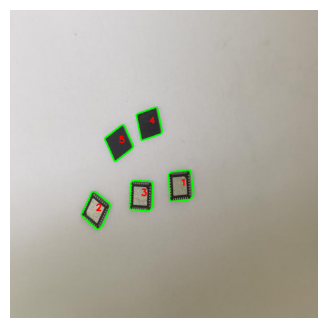

In [82]:
final_cnt_img = img.copy()

print("id valid area")
for i, (cnt, f) in enumerate(zip(sorted_contours, sorted_features)):
    f["id"] = i
    print(f"{f['id']} {f['valid']} {f['area']}")

    if f["valid"] == True:
        # draw contour
        cv2.drawContours(final_cnt_img, [cnt], -1, (0, 255, 0), 2)

        # put contour id
        id = f["id"]
        if f["m00"] != 0:
            cx = int(f["m10"] / f["m00"])
            cy = int(f["m01"] / f["m00"])

        else:
            x, y, w, h = f["bbox_x"], f["bbox_y"], f["bbox_w"], f["bbox_h"]
            cx, cy = x + w // 2, y + h // 2

        cv2.putText(final_cnt_img, str(id+1), (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)


plt.figure(figsize=(4,4))
plt.imshow(final_cnt_img)
plt.axis("off")
plt.show()